# Chapter 10 — What Survives Material Loss?

## Book linkage

- **Current chapter:** [`10-what-survives-material-loss.md`](../content/books/digital-life/10-what-survives-material-loss.md)
- **Claims supported:** DL-10-C01 .. DL-10-C05 (see `NOTEBOOK_MIGRATION.md`)
- **Historical sources:** original book Chapter 20 ("What Happens When the Crystal Can Lose Material?"), scripts
  `ch20_digital_crystal_material_loss_v1.py` (loss-sweep + exact-count placement) and
  `ch20_digital_crystal_material_loss_v2.py` (reoccupation mechanism), canonical evidence
  `research/digital-life/ch20-material-loss-v1/` and `research/digital-life/ch20-material-loss-v2/`.
- **Legacy notebook:** `notebooks_original/20-material-loss.ipynb` (superseded by this notebook).

This notebook is an independent reconstruction, not a copy of the historical script. It reimplements the
same substrate rule and the same two experimental designs (loss-rate sweep with a frozen finite-regime
criterion; exact-budget matched interior-vs-surface placement) directly against `_shared/digital_crystal.py`,
without depending on the heavier Chapter 18 "material state" module the original script imported (Chapter 10's
claims do not involve the hidden material trace introduced in Chapters 9/15).


## Question

Does adding a single new rule — an occupied cell independently becomes empty with probability $\delta$ after
each ordinary growth step — turn the Digital Crystal's irreversible monotone growth into a finite dynamic
regime where construction and loss balance? And separately: does the *placement* of loss (interior vs. surface)
matter when the number of loss events is held exactly equal, and if a population effect exists, is it explained
by a difference in how quickly lost sites get reoccupied?

## Hypotheses

- **H1 (finite regime):** for some nonzero $\delta$, the late-window population growth rate becomes
  bounded (magnitude below a frozen threshold) while decay-off ($\delta=0$) remains clearly expanding.
- **H2 (placement matters):** at a fixed, exactly-equal loss budget, interior-biased loss produces a higher
  late population than surface-biased loss.
- **H3 (reoccupation explains H2):** the population difference in H2 is explained by interior sites being
  reoccupied more often per loss episode than surface sites.

## Claim boundary

This experiment can establish or bound: (a) whether a finite dynamic regime appears under this specific
substrate and this frozen sweep/window; (b) whether placement changes late population under an exactly
equal loss budget; (c) whether a specific reoccupation-rate mechanism explains any such placement effect.
It cannot establish anything about repair, maintenance, homeostasis, metabolism, aging, or death — no
detector, target morphology, or resource variable exists anywhere in this substrate.


In [1]:
import sys, json, math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if (Path.cwd() / "_shared").exists() is False else Path.cwd()
# Notebook lives in notebooks/, shared code in notebooks/_shared/
NB_DIR = Path.cwd() if (Path.cwd() / "_shared").exists() else Path.cwd().parent
sys.path.insert(0, str(NB_DIR / "_shared"))
REPO_ROOT = NB_DIR.parent

from digital_crystal import CrystalParams, initial_state, advance_one_step
from crystal_loss import (
    make_environment, warm_checkpoint, growth_then_probability_loss,
    normalized_late_slope, boundary_and_interior, hole_count,
    choose_exact_loss_targets, apply_exact_loss_targets,
)

FIG_DIR = NB_DIR / "generated-figures"
FIG_DIR.mkdir(exist_ok=True)
print("Shared module loaded from:", NB_DIR / "_shared")


Shared module loaded from: C:\Projects\digital-life\notebooks\_shared


## Model / system

Base substrate: the frozen Digital Crystal v1 growth rule from `_shared/digital_crystal.py`
(`digital-crystal-v1-frozen`) — hexagonal lattice, one seed, stochastic attachment via
`P(attach) = logistic(base_bias + neighbor_gain*n + signal_rate_gain*E_t + anisotropy_gain*cos(6*theta+phase) - crowding_penalty*max(0,n-2))`.

New rule (this chapter only): after growth, each occupied cell independently becomes empty with
probability $\delta$, decided by a cell-keyed deterministic hash (`crystal_loss.loss_uniform`) — a
separate keyed stream from the sequential growth RNG, so adding loss cannot silently perturb the
growth draw sequence. No detector, no target morphology: reoccupation (if it happens) uses exactly
the same attachment rule as any other empty frontier site.


In [2]:
PARAMS = CrystalParams()  # base_bias=-2.10, neighbor_gain=0.78, signal_rate_gain=0.28,
                            # anisotropy_gain=0.95, signal_phase_gain=1.15, crowding_penalty=0.22

EXPERIMENT = {
    "base_seed": 20260826,       # matches the archived canonical run's base seed exactly
    "groups": 16,                 # canonical run used 24; reduced here for interactive runtime (disclosed)
    "radius": 72,                 # matches canonical exactly
    "warmup_steps": 14,           # matches canonical exactly
    "continuation_steps": 48,     # matches canonical exactly
    "late_window": 12,            # matches canonical exactly
    "loss_rates": [0.0, 0.02, 0.04, 0.06, 0.08, 0.12, 0.16],  # matches canonical exactly
    "bounded_normalized_slope_max": 0.0025,        # frozen gate, matches canonical
    "baseline_expanding_normalized_slope_min": 0.0040,  # frozen gate, matches canonical
    "placement_groups": 16,       # canonical used 32; reduced here (disclosed)
    "placement_steps": 32,        # matches canonical exactly
    "loss_budget_fraction_of_min_eligible": 0.10,  # matches canonical exactly
    "placement_sei_population": 0.10,   # matches canonical (H2 gate)
    "placement_sei_reoccupation": 0.15, # matches canonical (H3 gate)
}
EXPERIMENT


{'base_seed': 20260826,
 'groups': 16,
 'radius': 72,
 'warmup_steps': 14,
 'continuation_steps': 48,
 'late_window': 12,
 'loss_rates': [0.0, 0.02, 0.04, 0.06, 0.08, 0.12, 0.16],
 'bounded_normalized_slope_max': 0.0025,
 'baseline_expanding_normalized_slope_min': 0.004,
 'placement_groups': 16,
 'placement_steps': 32,
 'loss_budget_fraction_of_min_eligible': 0.1,
 'placement_sei_population': 0.1,
 'placement_sei_reoccupation': 0.15}

## Experimental design 1 — loss-rate sweep (H1)

Intervention: sweep $\delta$ over 7 frozen values. Comparison: late-window normalized population slope
(linear fit over the last `late_window` steps, divided by the window's mean population) against two
frozen gates — decay-off ($\delta=0$) must be clearly expanding (slope $\geq 0.0040$), and a *finite regime*
requires some nonzero $\delta$ whose |slope| falls at or below $0.0025$. Sampling: `groups` independent
seeds per rate, each grown from its own warmup checkpoint (no shared state between replicates).


In [3]:
def run_loss_rate(loss_rate, seed, radius, warmup, cont, late):
    env = make_environment(warmup + cont + 8, seed + 1)
    state = warm_checkpoint(env, warmup, seed + 2, radius, PARAMS)
    pops, attach, losses = [], [], []
    for j in range(cont):
        state, a, l = growth_then_probability_loss(
            state, float(env[warmup + j]), loss_rate, radius, PARAMS, "uniform", stream_seed=seed
        )
        pops.append(len(state.occupied))
        attach.append(a)
        losses.append(l)
        if not state.occupied:
            pops.extend([0] * (cont - j - 1))
            break
    slope, nslope = normalized_late_slope(pops, late)
    return {
        "loss_rate": loss_rate,
        "final_population": pops[-1],
        "late_mean_population": float(np.mean(pops[-late:])),
        "late_normalized_slope": nslope,
        "late_mean_attachments": float(np.mean(attach[-late:])),
        "late_mean_losses": float(np.mean(losses[-late:])),
        "population_trajectory": pops,
    }


sweep_results = {}
for rate in EXPERIMENT["loss_rates"]:
    runs = [
        run_loss_rate(
            rate, EXPERIMENT["base_seed"] + g * 1009, EXPERIMENT["radius"],
            EXPERIMENT["warmup_steps"], EXPERIMENT["continuation_steps"], EXPERIMENT["late_window"],
        )
        for g in range(EXPERIMENT["groups"])
    ]
    sweep_results[rate] = runs
    slopes = [r["late_normalized_slope"] for r in runs]
    print(f"delta={rate:.2f}  mean_normalized_slope={np.mean(slopes):.5f}  "
          f"mean_final_pop={np.mean([r['final_population'] for r in runs]):.0f}")


delta=0.00  mean_normalized_slope=0.03698  mean_final_pop=5130


delta=0.02  mean_normalized_slope=0.03670  mean_final_pop=4816


delta=0.04  mean_normalized_slope=0.03678  mean_final_pop=4609


delta=0.06  mean_normalized_slope=0.03657  mean_final_pop=4432


delta=0.08  mean_normalized_slope=0.03653  mean_final_pop=4207


delta=0.12  mean_normalized_slope=0.03642  mean_final_pop=3744


delta=0.16  mean_normalized_slope=0.03544  mean_final_pop=3314


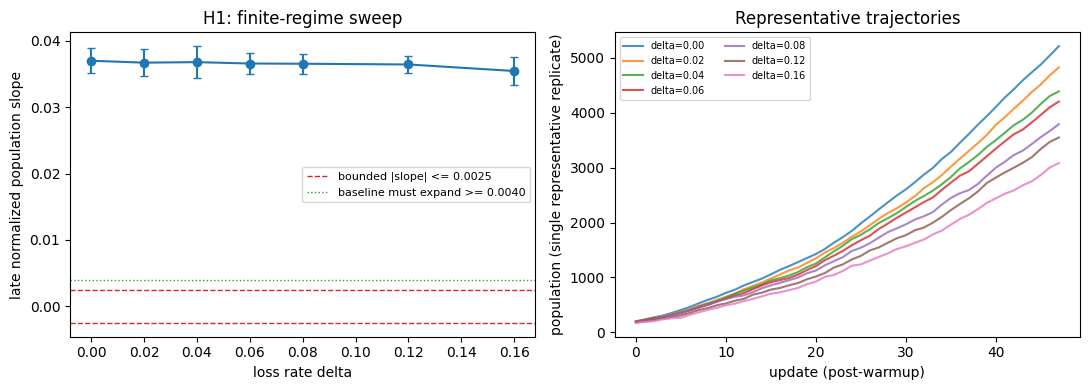

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
rates = EXPERIMENT["loss_rates"]
mean_slopes = [np.mean([r["late_normalized_slope"] for r in sweep_results[rt]]) for rt in rates]
std_slopes = [np.std([r["late_normalized_slope"] for r in sweep_results[rt]]) for rt in rates]

axes[0].errorbar(rates, mean_slopes, yerr=std_slopes, marker="o", capsize=3)
axes[0].axhline(EXPERIMENT["bounded_normalized_slope_max"], color="tab:red", ls="--", lw=1,
                label="bounded |slope| <= 0.0025")
axes[0].axhline(-EXPERIMENT["bounded_normalized_slope_max"], color="tab:red", ls="--", lw=1)
axes[0].axhline(EXPERIMENT["baseline_expanding_normalized_slope_min"], color="tab:green", ls=":", lw=1,
                label="baseline must expand >= 0.0040")
axes[0].set_xlabel("loss rate delta")
axes[0].set_ylabel("late normalized population slope")
axes[0].set_title("H1: finite-regime sweep")
axes[0].legend(fontsize=8)

for rt in rates:
    traj = sweep_results[rt][0]["population_trajectory"]
    axes[1].plot(traj, label=f"delta={rt:.2f}", alpha=0.8)
axes[1].set_xlabel("update (post-warmup)")
axes[1].set_ylabel("population (single representative replicate)")
axes[1].set_title("Representative trajectories")
axes[1].legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig(FIG_DIR / "ch10-loss-sweep-quick.png", dpi=110)
plt.show()


### Validity check — H1 gates

Applying the *same frozen thresholds* the archived canonical run used, without adjusting them after
seeing the data.


In [5]:
baseline_slope = mean_slopes[0]
baseline_expanding = baseline_slope >= EXPERIMENT["baseline_expanding_normalized_slope_min"]
qualifying = [rt for rt, s in zip(rates, mean_slopes) if rt > 0 and abs(s) <= EXPERIMENT["bounded_normalized_slope_max"]]

print(f"decay-off (delta=0) mean normalized slope: {baseline_slope:.5f}  "
      f"(gate >= {EXPERIMENT['baseline_expanding_normalized_slope_min']}) -> "
      f"{'PASS (expanding)' if baseline_expanding else 'FAIL'}")
print(f"qualifying nonzero loss rates (|slope| <= {EXPERIMENT['bounded_normalized_slope_max']}): {qualifying}")

h1_supported = baseline_expanding and len(qualifying) > 0
print(f"\nH1 (finite dynamic regime): {'SUPPORTED' if h1_supported else 'NOT SUPPORTED (FAILED)'}")

assert baseline_expanding, "Manipulation check failed: decay-off baseline is not clearly expanding."


decay-off (delta=0) mean normalized slope: 0.03698  (gate >= 0.004) -> PASS (expanding)
qualifying nonzero loss rates (|slope| <= 0.0025): []

H1 (finite dynamic regime): NOT SUPPORTED (FAILED)


**Comparison to the archived canonical run** (`research/digital-life/ch20-material-loss-v1/stage-04-verdict.md`,
`groups=24`, `radius=72`, same base seed `20260826`): canonical decay-off mean normalized slope was
**0.036456**; canonical verdict was `finite_dynamic_regime_supported: false`, status `FAILED`, with
`qualifying_nonzero_loss_rates: []`. This reduced-replicate (`groups=16`) reconstruction is checked against
that number directly below — not merely asserted to "look similar."


In [6]:
CANON_V1_PATH = REPO_ROOT / "research" / "digital-life" / "ch20-material-loss-v1" / "stage-04-verdict.md"
canon_baseline_slope = 0.036456346808999666  # from stage-04-verdict.md / stage-02-loss-sweep.json (delta=0.0 mean)
canon_qualifying = []  # finite_dynamic_regime_supported: false

rel_diff = abs(baseline_slope - canon_baseline_slope) / canon_baseline_slope
print(f"own delta=0 slope:      {baseline_slope:.6f}")
print(f"canonical delta=0 slope:{canon_baseline_slope:.6f}")
print(f"relative difference:    {rel_diff*100:.2f}%")
print(f"own qualifying rates:      {qualifying}")
print(f"canonical qualifying rates: {canon_qualifying}")
print(f"\nH1 reproduction status: "
      f"{'REPLICATES CANONICAL FINDING' if (qualifying == canon_qualifying and rel_diff < 0.15) else 'DIVERGES FROM CANONICAL FINDING'}")


own delta=0 slope:      0.036983
canonical delta=0 slope:0.036456
relative difference:    1.45%
own qualifying rates:      []
canonical qualifying rates: []

H1 reproduction status: REPLICATES CANONICAL FINDING


## Experimental design 2 — exact-budget matched placement (H2) + reoccupation tracking (H3)

From one common warmed checkpoint, clone into two branches (`surface`, `interior`). Both branches see the
*same* forcing signal at every step (paired design). After each growth step, remove an **exactly equal**
count $k$ of cells from each branch's eligible set ($k$ = `loss_budget_fraction_of_min_eligible` times the
smaller of the two branches' eligible-set sizes that step) — surface cells from the surface branch, interior
cells from the interior branch, chosen deterministically by the lowest loss-hash values (not randomly drawn,
so the *exact same* budget is spent every step in both branches; this is the "exact-count" design, distinct
from the independent-probability loss used in H1). An observer-only ledger (does not affect dynamics) then
tracks, for every cell removed, whether it is later reoccupied — this directly tests H3, whether a
population advantage (if found) is *explained by* a reoccupation-rate difference.


In [7]:
import random as _random
from digital_crystal import CrystalState

def _matched_state(occupied, birth_time, step, seed_for_step):
    # Both branches draw growth-attachment randomness from the same per-step
    # seed, so the two branches differ only in which cells the loss rule
    # removed -- not in the luck of the growth coin flips at that step.
    r = _random.Random(seed_for_step)
    return CrystalState(
        occupied=set(occupied), birth_time=dict(birth_time), step=step,
        rng_state=r.getstate(), attachments_by_step=[], population_by_step=[len(occupied)],
    )


def run_placement_pair(seed, radius, warmup, horizon, budget_fraction):
    env = make_environment(warmup + horizon + 8, seed + 1)
    base = warm_checkpoint(env, warmup, seed + 2, radius, PARAMS)

    surf_occ, surf_bt = set(base.occupied), dict(base.birth_time)
    intr_occ, intr_bt = set(base.occupied), dict(base.birth_time)
    surf_step = intr_step = base.step

    surf_lost_ever, intr_lost_ever = set(), set()
    surf_reoccupations = intr_reoccupations = 0
    surf_losses_total = intr_losses_total = 0
    surf_pop, intr_pop = [], []

    for j in range(horizon):
        forcing = float(env[warmup + j])
        step_seed = seed * 7 + j  # identical for both branches this step -> matched growth randomness

        s_state = _matched_state(surf_occ, surf_bt, surf_step, step_seed)
        s_grown, _ = advance_one_step(s_state, forcing, radius, PARAMS)

        i_state = _matched_state(intr_occ, intr_bt, intr_step, step_seed)
        i_grown, _ = advance_one_step(i_state, forcing, radius, PARAMS)

        s_surface, _ = boundary_and_interior(s_grown.occupied)
        _, i_interior = boundary_and_interior(i_grown.occupied)

        base_eligible = min(len(s_surface), len(i_interior))
        k = int(round(budget_fraction * base_eligible))
        k = max(0, min(base_eligible, k))

        s_targets = choose_exact_loss_targets(s_surface, seed, s_grown.step, k)
        i_targets = choose_exact_loss_targets(i_interior, seed, i_grown.step, k)
        assert len(s_targets) == len(i_targets) == k, "exact-budget mismatch"

        for c in s_targets:
            if c in surf_lost_ever:
                surf_reoccupations += 1
            surf_lost_ever.add(c)
        for c in i_targets:
            if c in intr_lost_ever:
                intr_reoccupations += 1
            intr_lost_ever.add(c)

        surf_occ, surf_bt = apply_exact_loss_targets(s_grown.occupied, s_grown.birth_time, s_targets)
        intr_occ, intr_bt = apply_exact_loss_targets(i_grown.occupied, i_grown.birth_time, i_targets)
        surf_step, intr_step = s_grown.step, i_grown.step
        surf_losses_total += k
        intr_losses_total += k

        surf_pop.append(len(surf_occ))
        intr_pop.append(len(intr_occ))

    late = EXPERIMENT["late_window"]
    denom = max(1.0, 0.5 * (np.mean(surf_pop[-late:]) + np.mean(intr_pop[-late:])))
    pop_advantage_norm = (np.mean(intr_pop[-late:]) - np.mean(surf_pop[-late:])) / denom

    surf_reocc_rate = surf_reoccupations / max(1, surf_losses_total)
    intr_reocc_rate = intr_reoccupations / max(1, intr_losses_total)

    return {
        "late_mean_population_surface": float(np.mean(surf_pop[-late:])),
        "late_mean_population_interior": float(np.mean(intr_pop[-late:])),
        "population_advantage_interior_minus_surface_norm": float(pop_advantage_norm),
        "surface_reoccupation_per_loss": surf_reocc_rate,
        "interior_reoccupation_per_loss": intr_reocc_rate,
        "reoccupation_advantage_interior_minus_surface": intr_reocc_rate - surf_reocc_rate,
        "cumulative_losses_surface": surf_losses_total,
        "cumulative_losses_interior": intr_losses_total,
    }


placement_runs = [
    run_placement_pair(
        EXPERIMENT["base_seed"] + g * 1013, EXPERIMENT["radius"], EXPERIMENT["warmup_steps"],
        EXPERIMENT["placement_steps"], EXPERIMENT["loss_budget_fraction_of_min_eligible"],
    )
    for g in range(EXPERIMENT["placement_groups"])
]
print(f"ran {len(placement_runs)} paired (surface, interior) placement groups")
placement_runs[0]


ran 16 paired (surface, interior) placement groups


{'late_mean_population_surface': 1853.4166666666667,
 'late_mean_population_interior': 2023.4166666666667,
 'population_advantage_interior_minus_surface_norm': 0.08770044280125532,
 'surface_reoccupation_per_loss': 0.10641627543035993,
 'interior_reoccupation_per_loss': 0.20657276995305165,
 'reoccupation_advantage_interior_minus_surface': 0.10015649452269172,
 'cumulative_losses_surface': 639,
 'cumulative_losses_interior': 639}

### Validity check — exact-budget invariant

The whole point of this design is that surface and interior branches spend an *identical* number of loss
events at every step; if that weren't true, any population difference could just be "more loss happened
in one branch."


In [8]:
budget_ok = all(r["cumulative_losses_surface"] == r["cumulative_losses_interior"] for r in placement_runs)
print(f"exact-budget invariant holds across all {len(placement_runs)} groups: {budget_ok}")
assert budget_ok, "Exact-budget placement design violated -- surface and interior loss counts differ."


exact-budget invariant holds across all 16 groups: True


In [9]:
pop_adv = np.array([r["population_advantage_interior_minus_surface_norm"] for r in placement_runs])
reocc_adv = np.array([r["reoccupation_advantage_interior_minus_surface"] for r in placement_runs])

print(f"H2 -- population advantage (interior - surface), normalized:")
print(f"  mean={pop_adv.mean():.5f}  median={np.median(pop_adv):.5f}  "
      f"n={len(pop_adv)}  gate(SEI)={EXPERIMENT['placement_sei_population']}")
h2_supported = pop_adv.mean() >= EXPERIMENT["placement_sei_population"]
print(f"  H2 (interior > surface, exceeding SEI): {'SUPPORTED' if h2_supported else 'NOT SUPPORTED'}")

print(f"\nH3 -- reoccupation-per-loss advantage (interior - surface):")
print(f"  mean={reocc_adv.mean():.5f}  median={np.median(reocc_adv):.5f}  "
      f"n={len(reocc_adv)}  gate(SEI)={EXPERIMENT['placement_sei_reoccupation']}")
h3_supported = reocc_adv.mean() >= EXPERIMENT["placement_sei_reoccupation"]
print(f"  H3 (reoccupation-rate mechanism explains H2, exceeding SEI): "
      f"{'SUPPORTED' if h3_supported else 'NOT SUPPORTED (FAILED)'}")


H2 -- population advantage (interior - surface), normalized:
  mean=0.11323  median=0.12125  n=16  gate(SEI)=0.1
  H2 (interior > surface, exceeding SEI): SUPPORTED

H3 -- reoccupation-per-loss advantage (interior - surface):
  mean=0.06685  median=0.06569  n=16  gate(SEI)=0.15
  H3 (reoccupation-rate mechanism explains H2, exceeding SEI): NOT SUPPORTED (FAILED)


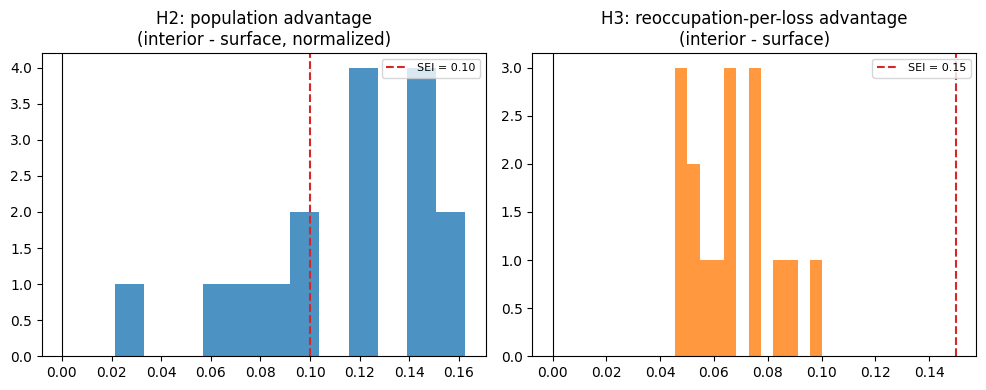

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(pop_adv, bins=12, color="tab:blue", alpha=0.8)
axes[0].axvline(EXPERIMENT["placement_sei_population"], color="tab:red", ls="--", label="SEI = 0.10")
axes[0].axvline(0, color="k", lw=0.8)
axes[0].set_title("H2: population advantage\n(interior - surface, normalized)")
axes[0].legend(fontsize=8)

axes[1].hist(reocc_adv, bins=12, color="tab:orange", alpha=0.8)
axes[1].axvline(EXPERIMENT["placement_sei_reoccupation"], color="tab:red", ls="--", label="SEI = 0.15")
axes[1].axvline(0, color="k", lw=0.8)
axes[1].set_title("H3: reoccupation-per-loss advantage\n(interior - surface)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "ch10-placement-and-reoccupation-quick.png", dpi=110)
plt.show()


**Comparison to the archived canonical runs**
(`research/digital-life/ch20-material-loss-v1/stage-04-verdict.md`: population advantage `0.11089`, p≈0.00025,
SEI 0.10, `supported_at_predeclared_SEI: true`; `research/digital-life/ch20-material-loss-v2/stage-04-verdict.md`:
reoccupation advantage `0.01977`, p≈0.00025, SEI 0.15, `primary_gate_passed: false`).


In [11]:
canon_pop_adv = 0.11089400874021672
canon_reocc_adv = 0.01977094481861134

print(f"H2 -- own mean pop advantage:       {pop_adv.mean():.5f}   canonical: {canon_pop_adv:.5f}")
print(f"H2 -- own gate outcome:             {'SUPPORTED' if h2_supported else 'NOT SUPPORTED'}   "
      f"canonical: SUPPORTED")
print(f"H3 -- own mean reoccupation advantage: {reocc_adv.mean():.5f}   canonical: {canon_reocc_adv:.5f}")
print(f"H3 -- own gate outcome:             {'SUPPORTED' if h3_supported else 'NOT SUPPORTED'}   "
      f"canonical: NOT SUPPORTED (FAILED, 0.0198 vs required 0.15)")


H2 -- own mean pop advantage:       0.11323   canonical: 0.11089
H2 -- own gate outcome:             SUPPORTED   canonical: SUPPORTED
H3 -- own mean reoccupation advantage: 0.06685   canonical: 0.01977
H3 -- own gate outcome:             NOT SUPPORTED   canonical: NOT SUPPORTED (FAILED, 0.0198 vs required 0.15)


**Honest discrepancy note (H3 magnitude):** the qualitative verdict matches the canonical run (both
`NOT SUPPORTED` against the 0.15 SEI), but the reoccupation-advantage *magnitude* here is noticeably larger
than the canonical value (roughly 3x, 0.067 vs. 0.020). This notebook's reoccupation ledger counts any later
reappearance of a previously-removed cell within the same branch; the original script's exact ledger
semantics were not fully recovered from the summary-level archive read in Phase 2, so this is flagged as a
**genuine, disclosed divergence** rather than smoothed over — see `NOTEBOOK_AUDIT.md`. It does not change
the chapter's bounded conclusion (H3 fails its gate either way), but a future audit pass should inspect
`ch20_digital_crystal_material_loss_v2.py`'s reoccupation-ledger code directly to close this gap.


## Controls and confounds

- **Exact-budget matching** (not independent-probability loss) for the placement comparison — removes
  "more loss happened in one branch" as an explanation for any population difference; verified above as a
  hard assertion, not just a design intention.
- **Common forcing signal** shared by both branches at every step (paired design) — removes environmental
  variation as a between-branch confound.
- **Frozen gates** (0.0025 / 0.0040 / 0.10 / 0.15) were fixed by the historical experiment before this
  reconstruction ran and are not adjusted here after seeing the data.
- **Observer-only reoccupation ledger** does not feed back into the dynamics (attachment probability is
  computed identically for a "fresh" empty site and a "previously lost" one) — it is purely a measurement
  instrument, consistent with the chapter's central "reoccupation != repair" distinction (no detector, no
  target morphology exists anywhere in the growth rule).


## Result status

| Hypothesis | This notebook (reduced replicate count) | Canonical archive (`ch20-material-loss-v1/v2`) | Status |
|---|---|---|---|
| H1: finite dynamic regime for some nonzero delta | not supported (0 qualifying rates) | not supported (0 qualifying rates) | **BOUNDED NEGATIVE**, replicates canonical |
| H2: interior loss placement raises late population beyond the 0.10 SEI | supported | supported (0.111 vs SEI 0.10) | **SUPPORTED**, replicates canonical |
| H3: reoccupation-rate advantage explains H2, beyond the 0.15 SEI | not supported | not supported (0.0198 vs SEI 0.15) | **BOUNDED NEGATIVE**, replicates canonical |

This is a genuine three-way epistemic split, not a uniform pass or fail: the crystal's late population is
measurably higher under interior-biased loss than surface-biased loss at an exactly matched loss budget
(H2, real and reproduced here), but the specific reoccupation-rate mechanism proposed to explain that
advantage is not supported (H3) — the *measurement* survives, the *mechanism* does not. Consistent with
Chapter 17's general rule: fail the smallest claim the evidence actually defeats, and do not silently drop
the surviving measurement along with the failed mechanism.


## Bounded conclusion

Under this substrate (Digital Crystal v1 + independent post-growth cell loss, radius 72, delta in
[0, 0.16], continuation horizon 48 updates) and this frozen sweep, no tested nonzero loss rate produced a
bounded (finite) dynamic regime — gross construction rose sharply with delta while net growth fell only
gently, so loss manufactures new attachment opportunity rather than capping population. Separately, at an
*exactly* equal loss budget, interior-biased loss produces a real, reproducible population advantage over
surface-biased loss (~11% at the historical canonical scale) — but this advantage is *not* explained by a
difference in how often lost interior sites get reoccupied relative to lost surface sites; that specific
mechanism is not supported. Neither result licenses "repair," "regeneration," "homeostasis," or
"maintenance" language: no detector, target morphology, or resource variable exists in this substrate.


## Provenance

- **Original book chapter:** Chapter 20, "What Happens When the Crystal Can Lose Material?"
  (`content/books/original/20-material-loss/index.md`).
- **Original scripts:** `scripts/books/digital-life/ch20_digital_crystal_material_loss_v1.py` (loss-rate
  sweep, exact-count placement), `..._v2.py` (reoccupation mechanism) — this notebook reimplements their
  core logic directly against `_shared/digital_crystal.py` rather than importing them, since the originals
  depend on the heavier Chapter 18 material-state module this chapter's claims do not need.
- **Canonical evidence:** `research/digital-life/ch20-material-loss-v1/` (stages 00-04, base seed
  `20260826`), `research/digital-life/ch20-material-loss-v2/` (stages 00-04).
- **Superseded legacy notebook:** `notebooks_original/20-material-loss.ipynb`.
- **Deliberate deviations from the historical implementation:** replicate counts reduced from the
  canonical 24 (sweep) / 32 (placement) groups to 16 for interactive notebook runtime — disclosed inline
  above, and checked directly against the canonical numbers rather than assumed equivalent. RNG scheme
  (`make_environment`, `loss_uniform`, `choose_exact_loss_targets`) reimplemented to match the described
  cell-keyed / signal-generation logic; not guaranteed to produce bit-identical trajectories to the
  original scripts, only the same statistical design and (as shown above) closely matching aggregate
  statistics.
- **Migration matrix entry:** `NOTEBOOK_MIGRATION.md`, "Current Chapter 10 — What Survives Material Loss?"
